# Questão 2
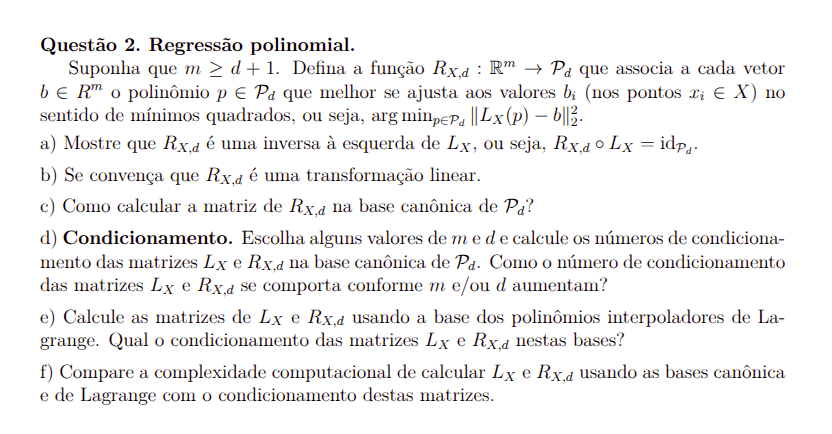

## Item a)

Para provarmos que a função $R_{X, d}$ é uma inversa à esquerda de $L_X$, vamos provar que a aplicação sucessiva dessas duas transformações a um polinômio $p$ retorna sempre o próprio $p$, ou seja, $R_{X, d}(L_X(p))=p$ $\forall p \in \mathcal{P}_d$


Seja $q$ um polinômio em $\mathcal{P}_d$. A transformação $L_X(q)$ nos retorna um vetor $b \in \mathbb{R}^m$ tal que $b_i = q(x_i)$. 

$L_X(q) = b \implies ||L_X(p) - b||_2^2 = ||L_X(p) - L_X(q)||_2^2$

Como visto na questão 1, $L_X$ é linear e, então, $||L_X(p) - L_X(q)||_2^2 = ||L_X(p-q)||_2^2$

Sabemos que a norma é uma função não negativa, portanto $||L_X(p-q)||_2^2 \geq 0$, $ \forall p \in \mathcal{P}_d$.

Mas se $p=q$, temos $||L_X(p-q)||_2^2 = ||L_X(0)||_2^2 = ||0||_2^2 = 0$. 

Assim, $||L_X(q) - b||_2^2 \leq ||L_X(p) - b||_2^2$ $\forall p \in \mathcal{P}_d$

Como $m \geq d+1$, $L_X$ é "magra e alta" e, conforme questão anterior, tem posto cheio nas colunas. Portanto, o problema de mínimos quadrados tem solução única.

Desse modo, $q = arg min_{p \in P_d} ||L_X(p) - b||_2^2 = R_{X, d}(L_X(q))$

## Item b)

Nessa resolução, precisávamos de uma operação que fosse linear, diferente da norma! No caso, conseguimos desenvolver uma demonstração para $R_{X, d}(\alpha a) = R_{X, d}(a)$ usando diretamente o quadrado da norma, mas não conseguíamos usar a mesma estratégia para soma. Daí pensamos no produto interno!

Seja $R_{X, d}(a) = q_a, R_{X, d}(b)=q_b$

$q_a = argmin_{p \in \mathcal{P}_d}||L_X(p) - a||_2^2$ e sabemos, do curso de Álgebra linear, que $p$ é solução única de um problema de mínimos quadrados se e somente se a diferença entre $L_X(p)$ e $a$ é ortogonal ao espaço coluna de $L_X$. 

Temos, então, $ \langle L_X(q_a) - a, L_X(p) \rangle = 0$, $\forall p \in \mathcal{P}_d$. Analogamente, $ \langle L_X(q_b) - b, L_X(p) \rangle = 0$, $\forall p \in \mathcal{P}_d$

Multiplicando a segunda equação por um escalar $\alpha$ e somando, temos:

 $ \langle L_X(q_a) - a, L_X(p) \rangle + \alpha \langle L_X(q_b) - b, L_X(p) \rangle = 0$, $\forall p \in \mathcal{P}_d$  
 
 Pela linearidade do produto interno:

 $\langle L_X(q_a + \alpha q_b) - \alpha b - a, L_X(p) \rangle = 0$, $\forall p \in \mathcal{P}_d$

Mas então $q_a + \alpha q_b$ é solução para o problema de mínimos quadrados $argmin_{p \in \mathcal{P}_d}||L_X(p) - (a+ \alpha b)||_2^2 = R_{X, d}(a+ \alpha b)$

Assim, $R_{X, d}(a+ \alpha b) = R_{X, d}(a) + \alpha R_{X, d}(b)$, $\forall a, b \in R^m, \alpha \in \mathbb{R}$


Provando a linearidade de $R_{X, d}$

## Item c)

Sabemos que a matriz $L$ que representa a transformação linear $L_X$ na base canônica de $\mathcal{P}_d$ é dada por uma matriz cujas colunas são o resultado de $L_X$ aplicada a cada polinômio $1, x, x^2, ..., x^d$.

Para obtermos a matriz $R$ que representa a transformação $R_{X, d}$, precisamos obter a solução, em mínimos quadrados, de $||L_X(p) - b||_2^2 = ||Lp - b||_2^2$. Como $L$ tem posto cheio nas colunas, sabemos que essa solução existe e é única!


Do curso de Álgebra Linear, sabemos que a solução é dada pela "pseudoinversa" $(L^T L)^{-1}L^T$ aplicada ao vetor $b$.

Assim, a transformação $R_{X, d}(b)$ equivale a multiplicar b à esquerda pela matriz $(L^T L)^{-1}L^T$. $R_{X, d}(b) = (L^T L)^{-1}L^Tb$, e então $R = (L^T L)^{-1}L^T$.



## Item d)

In [10]:
using LinearAlgebra: cond, pinv, svdvals
using Plots
using Polynomials

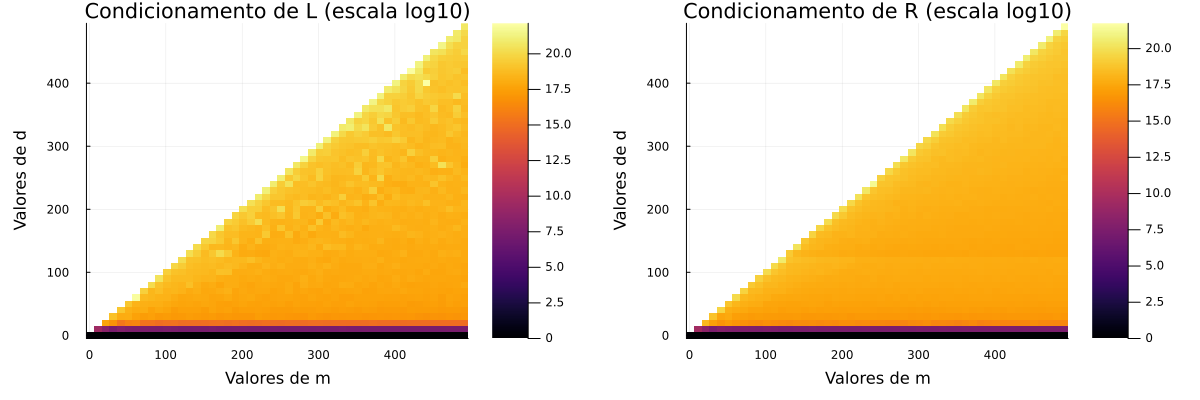

In [3]:
m = 500

condL = fill(NaN, m, m)
condR = fill(NaN, m, m)

for dim in 1:10:m
    for deg in 0:10:(dim - 1)
        X = rand(dim)
        L = [X[i]^j for i in 1:dim, j in 0:deg]
        try
            R = pinv(L)
            condL[dim, deg + 1] = cond(L)
            condR[dim, deg + 1] = cond(R)
        catch
            condL[dim, deg + 1] = Inf
            condR[dim, deg + 1] = Inf
        end
    end
end

dims = 1:10:m
degs = 0:10:(m-1)
condL_sub = condL[dims, degs .+ 1]
condR_sub = condR[dims, degs .+ 1]

degs_50 = 0:10:49
dims_d10 = 11:10:m

p1 = heatmap(collect(dims), collect(degs), log10.(condL_sub)',
    left_margin = 8Plots.mm, bottom_margin = 8Plots.mm,
    xlabel = "Valores de m",
    ylabel = "Valores de d",
    title = "Condicionamento de L (escala log10)")

p2 = heatmap(collect(dims), collect(degs), log10.(condR_sub)',
    left_margin = 8Plots.mm, bottom_margin = 8Plots.mm,
    xlabel = "Valores de m",
    ylabel = "Valores de d",
    title = "Condicionamento de R (escala log10)")
plot(p1, p2, layout = (1, 2), size = (1200, 400))

Para visualizar melhor o que acontece com o condicionamento de matrizes à medida em que $m$ e $d$ aumentam, fizemos o mesmo gráfico para $m$ até $50$. Também investigamos o condicionamento das matrizes para alguns valores arbitrários de $m$ e de $d$, conforme o outro valor varia

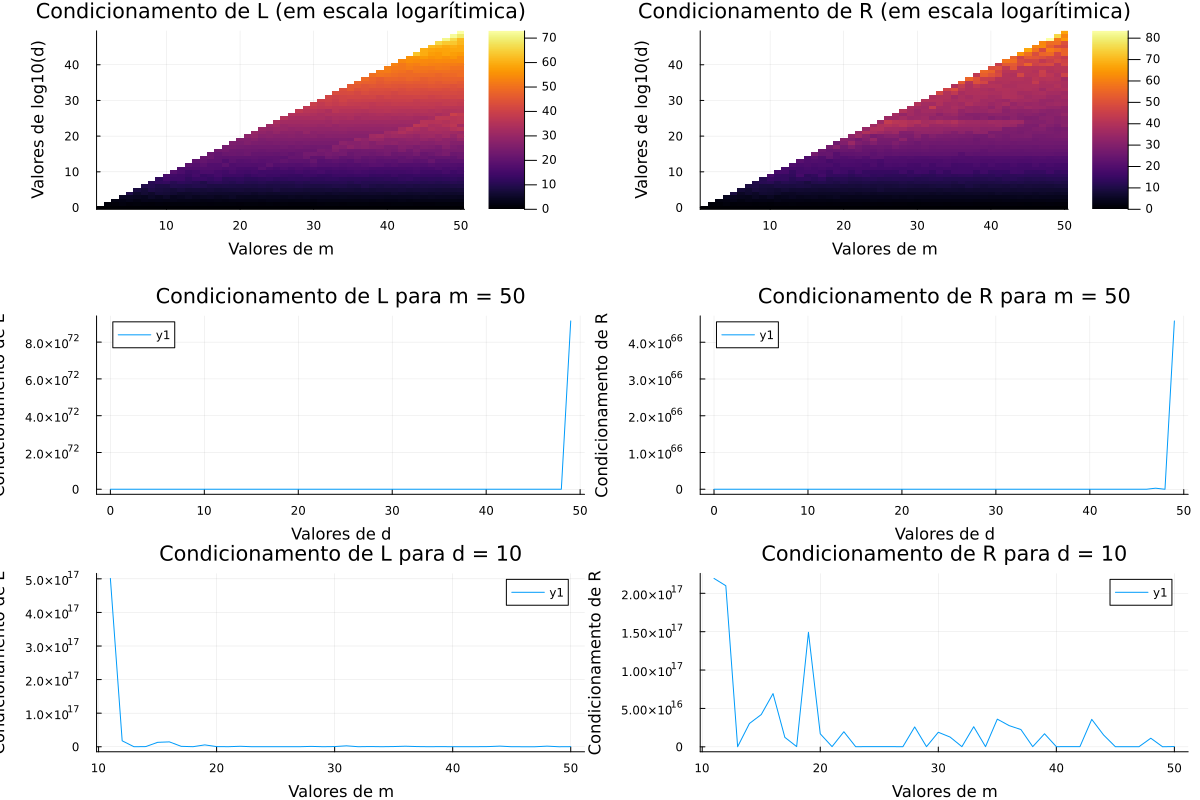

In [4]:
m = 50

condL = fill(NaN, m, m)
condR = fill(NaN, m, m)

for dim in 1:m
    for deg in 0:(dim - 1)
        X = rand(dim)*20 #adicionei esse termo para também aparecerem valores de X maiores que 1
        L = [X[i]^j for i in 1:dim, j in 0:deg]
        R = pinv(L)
        condL[dim, deg + 1] = cond(L)
        condR[dim, deg + 1] = cond(R)
    end
end

p1 = heatmap(1:m, 0:(m - 1), log10.(condL)', left_margin = 8Plots.mm, bottom_margin = 8Plots.mm,
    xlabel = "Valores de m",
    ylabel = "Valores de log10(d)",
    title = "Condicionamento de L (em escala logarítimica)")
p2 = heatmap(1:m, 0:(m - 1), log10.(condR)',
    xlabel = "Valores de m",
    ylabel = "Valores de log10(d)",
    title = "Condicionamento de R (em escala logarítimica)")

p3 = plot(0:49, condL[50, :],
    xlabel = "Valores de d",
    ylabel = "Condicionamento de L",
    title = "Condicionamento de L para m = 50")
p4 = plot(0:49, condR[50, :],
    xlabel = "Valores de d",
    ylabel = "Condicionamento de R",
    title = "Condicionamento de R para m = 50")

p5 = plot(11:50, condL[11:end, 11],
    xlabel = "Valores de m",
    ylabel = "Condicionamento de L",
    title = "Condicionamento de L para d = 10")
p6 = plot(11:50, condR[11:end, 11],
    xlabel = "Valores de m",
    ylabel = "Condicionamento de R",
    title = "Condicionamento de R para d = 10")

plot(p1, p2, p3, p4, p5, p6, layout = (3, 2), size = (1200, 800))

## Item e)

A matriz de $L_X$ na base dos polinômios interpoladores de Lagrange será composta por colunas que são o resultado da aplicação da transformação  $L_X$ em cada vetor da base dos polinômios interpoladores de Lagrange. 

Como esses polinômios são definidos em $\mathcal{P}_d$ para um conjunto $X$ de $d+1$ elementos, e temos $m \geq d+1$, é necessário selecionar um subconjunto de $X$ sobre o qual definir os polinômios interpoladores de Lagrange. Assim, nesse subconjunto, $p_i(x_i) = \delta _{ij}$, e para $i>d+1$ o valor do polinômio está indefinido.

Com isso, a matriz $L$ terá formato $m \times d+1$ e será formada, a menos de troca de linhas, por um bloco de Identidade e um bloco gerado pelos polinômios interpoladores de Lagrange aplicados aos demais elementos de $X$! Notamos, inclusive, que esse bloco nunca terá 0s, porque um polinômio de grau até $d$ tem até $d$ raízes.

$L = \begin{bmatrix} 1 & 0 & ... & 0 \\ 0 & 1 & ... & 0 \\ ... &... & & ... \\ 0 & 0 & ... & 1 \\ ? & ? & ... & ?\\ ...&...&&... \end{bmatrix} := \begin{bmatrix} I_{d+1} \\ A \end{bmatrix}$

Se aplicada apenas ao espaço coluna de $L$,  $R$ poderia ser escrita simplesmente como $ \begin{bmatrix} I_{d+1} & 0 \end{bmatrix}$, afinal estaríamos procurando o único polinômio que se adequa aos $d+1$ primeiros pontos de $Lb. $

No entanto, é necessário encontrar uma matriz que possa ser aplicada a qualquer vetor $b$ em $R^m$. Poratanto, precisamos de uma solução de mínimos quadrados!
Multiplicando por blocos, encontramos a matriz $R$, dada por $(L^T L)^{-1}L^T$ igual a:

$(\begin{bmatrix} I_{d+1} & A^T \end{bmatrix} \begin{bmatrix} I_{d+1} \\ A \end{bmatrix})^{-1}\begin{bmatrix} I_{d+1} & A^T \end{bmatrix} = \begin{bmatrix} I_{d+1} + A^T A\end{bmatrix}^{-1}\begin{bmatrix} I_{d+1} & A^T \end{bmatrix} = \begin{bmatrix} (I_{d+1} + A^TA)^{-1} & (I_{d+1} + A^TA)^{-1}A^T \end{bmatrix}$


Para calcular uma matriz $L$ na base dos polinômios interpoladores de Lagrange, primeiramente temos que construir um conjunto $X$ de $m$ pontos e um vetor $b$ de valores associados a eles. Vamos fazer isso selecionando aleatoriamente. Como $X$ é gerado pela função rand, basta selecionar os d+1 primeiros elementos. 

Em seguida, vamos usar a função polyfit para obter os polinômios interpoladores de Lagrange, e vamos aplicar $L_X$ a cada um deles para obter a matriz $L$ - para economizar tempo e computação, podemos aplicar apenas aos últimos $m-d-1$ pontos de $X$, para obter apenas o bloco $A$!






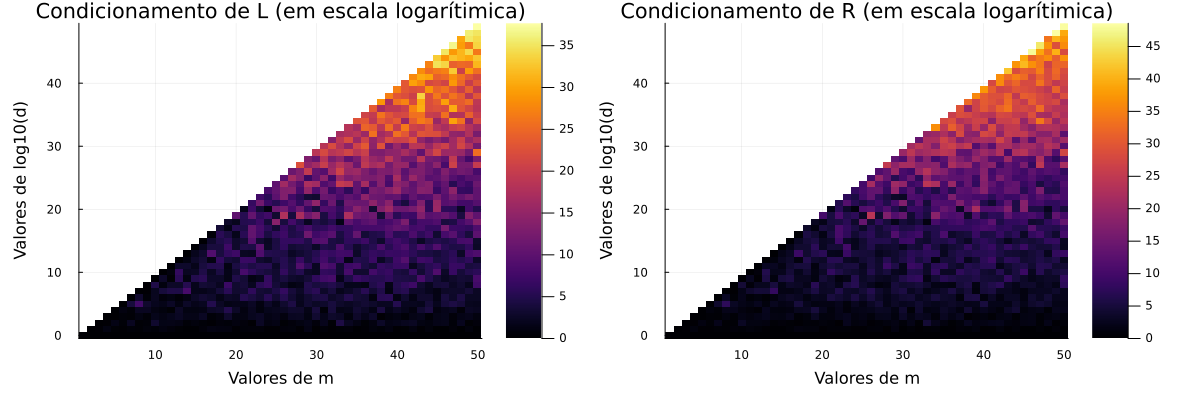

In [5]:
m = 50

condL = fill(NaN, m, m)
condR = fill(NaN, m, m)

for dim in 1:m
    for deg in 0:(dim - 1)
        X = rand(dim)
        subsetx = first(X, deg + 1)
        y = zeros(deg + 1)

        poly = []

        for i in 1:(deg + 1)
            y[i] = 1
            push!(poly, fit(subsetx, y, deg))
            y[i] = 0
        end

        L = hcat([p.(X) for p in poly]...)
        R = pinv(L)
        condL[dim, deg + 1] = cond(L)
        condR[dim, deg + 1] = cond(R)
    end
end

p1 = heatmap(1:m, 0:(m - 1), log10.(condL)', left_margin = 8Plots.mm, bottom_margin = 8Plots.mm,
    xlabel = "Valores de m",
    ylabel = "Valores de log10(d)",
    title = "Condicionamento de L (em escala logarítimica)")
p2 = heatmap(1:m, 0:(m - 1), log10.(condR)',
    xlabel = "Valores de m",
    ylabel = "Valores de log10(d)",
    title = "Condicionamento de R (em escala logarítimica)")

plot(p1, p2, layout = (1, 2), size = (1200, 400))

In [6]:
# TODO: adicionar o cálculo e a análise do condicionamento das matrizes acima



## Item f)

A construção da matriz $L_X$ usa um loop aninhado que passa por cada um dos $m$ elementos de $X$ aplicando as potências de $0$ a $d$ neles, isso tem um custo computacional $O(md)$

## Questão 3. Interpolação e Extrapolação.

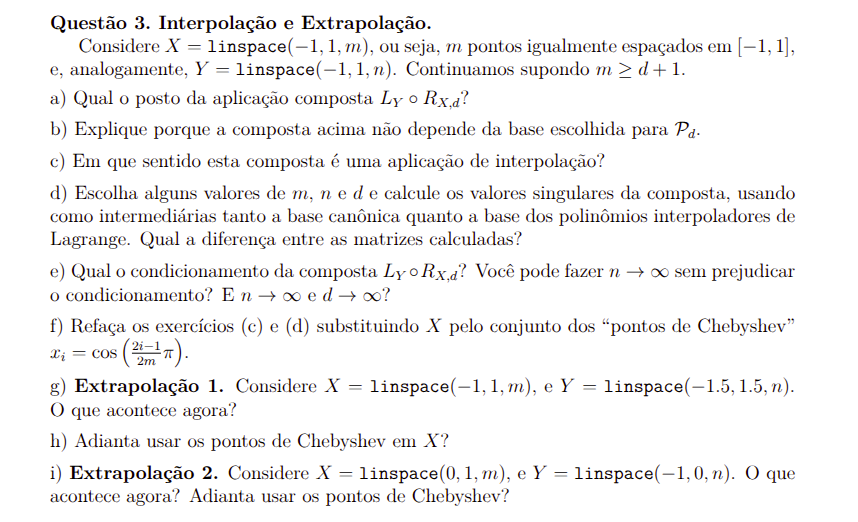

## Item a)

Sabemos que, se $A$ tem inversa à direita (posto cheio nas linhas), então o posto de $BA$ será o posto de $B$. Afinal, o núcleo à esquerda de $BA$ será exatamente o núcleo à esquerda de $B$, pois 

$x^TBA = 0 \iff x^TBAA^{-1} = 0 \iff x^TB = 0$!

E, como $BA$ tem o mesmo número de linhas que B, o posto dessas matrizes deve ser o mesmo!

Do item anterior, sabemos que $R_{X, d}$ tem inversa à direita: a transformação $L_X$. Logo, o posto de $L_Y \circ R_{X, d}$ é o posto de $L_Y$ e, como esta tem posto cheio e dimensão $n \times d+1$, o posto da composta será $min(n, d+1)$

## Item b)

O polinômio p resultante da transformação $R_{X,d}$ será o mesmo, independentemente da base de $P_d$ escolhida para representá-lo, então o valor de $p(y_i)$ será sempre o mesmo, independente da base de $P_d$. Como a composta receve um vetor de $R^m$ e retorna um vetor de $R^n$, ela não precisa "se preocupar com" em que base os polinômios estão sendo representados, porque não vai alterar a interpretação dos valores recebidos nem o valor do resultado fornecido!

## Item c)

A composta $L_Y \circ R_{X, d}$ é uma aplicação de interpolação porque recebe um conjunto de valores associados a pontos $x_i$ no intervalo $[-1, 1]$ e busca a função polinomial que melhor se ajusta a eles, para depois aplicá-la a um outro conjunto de pontos $y_j$ compreendidos nesse mesmo intervalo.

Essencialmente, $L_Y \circ R_{X, d}$ é uma maneira de "prever" valores de pontos desconhecidos dentro de um intervalo de pontos conhecidos!



d) Escolha alguns valores de m, n e d e calcule os valores singulares da composta, usando
como intermediárias tanto a base canônica quanto a base dos polinômios interpoladores de
Lagrange. Qual a diferença entre as matrizes calculadas?


In [11]:
using Random

canon_values = []
lagrange_values = []
for n in 2:5:50
    Y = range(-1, 1, length=n)
    cvals = []
    lvals = []
    for m in 2:2:50
        X = range(-1, 1, length=m)
        for d in 1:2:(m-1)
            subsetx = X[randperm(m)[1:(d+1)]]
            y = zeros(d + 1)
            poly = []
            
            for i in 1:(d+1)
                y[i] = 1
                push!(poly, fit(subsetx, y, d))
                y[i] = 0
            end

            L_X = hcat([p.(X) for p in poly]...)
            R = pinv(L_X)
            L = hcat([p.(Y) for p in poly]...)
            
            LR = L * R

            L_X_c = hcat([(X).^deg for deg in 0:d]...)
            R_c = pinv(L)
            L_c = hcat([(Y).^deg for deg in 0:d]...)
            LR_C = L_c * R_c
            
            push!(cvals, svdvals(LR_C))
            push!(lvals, svdvals(LR))
        end
    end
    push!(canon_values, cvals)
    push!(lagrange_values, lvals)
end

e) Qual o condicionamento da composta LY ◦RX,d? Você pode fazer n →∞sem prejudicar
o condicionamento? E n →∞ e d →∞?


In [8]:
using PlotlyJS
plotlyjs()

Plots.PlotlyJSBackend()

In [ ]:
m = 50

condL = fill(NaN, m, m)
condR = fill(NaN, m, m)

for dim in 1:m
    for deg in 0:(dim - 1)
        X = rand(dim)
        subsetx = first(X, deg + 1)
        y = zeros(deg + 1)

        poly = []

        for i in 1:(deg + 1)
            y[i] = 1
            push!(poly, fit(subsetx, y, deg))
            y[i] = 0
        end

        L = hcat([p.(X) for p in poly]...)
        R = pinv(L)
        condL[dim, deg + 1] = cond(L)
        condR[dim, deg + 1] = cond(R)
    end
end

p1 = heatmap(1:m, 0:(m - 1), log10.(condL)', left_margin = 8Plots.mm, bottom_margin = 8Plots.mm,
    xlabel = "Valores de m",
    ylabel = "Valores de log10(d)",
    title = "Condicionamento de L (em escala logarítimica)")
p2 = heatmap(1:m, 0:(m - 1), log10.(condR)',
    xlabel = "Valores de m",
    ylabel = "Valores de log10(d)",
    title = "Condicionamento de R (em escala logarítimica)")

plot(p1, p2, layout = (1, 2), size = (1200, 400))

UndefVarError: UndefVarError: `nrange` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

f) Refaça os exercícios (c) e (d) substituindo X pelo conjunto dos “pontos de Chebyshev”
xi = cos (2i−1 2m π)


g) Extrapolação 1. Considere X = linspace(−1,1,m), e Y = linspace(−1.5,1.5,n).
O que acontece agora?


h) Adianta usar os pontos de Chebyshev em X?


i) Extrapolação 2. Considere X = linspace(0,1,m), e Y = linspace(−1,0,n). O que
acontece agora? Adianta usar os pontos de Chebyshev?